# Concrete Compressive Strength Predictor
**Author:** Nicolás Ignacio Rivolta
**Tools:** pandas · matplotlib · seaborn · scikit-learn · XGBoost · Anthropic API
**Dataset:** UCI Concrete Compressive Strength (1,030 samples, 8 features)

> Predicting concrete compressive strength using machine learning.
> Domain knowledge from Civil Engineering (UNNE) informs feature interpretation.

In [222]:
# Install all required libraries
!pip install pandas matplotlib seaborn scikit-learn xgboost openpyxl anthropic --quiet


162896.11s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


I0826 13:23:08.904561 1272110 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(147, generation: 1)
I0826 13:23:08.904616 1272110 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(150, generation: 1)

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [223]:
# ── Imports ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded successfully")

✅ All libraries loaded successfully


## 1. Load & Explore the Dataset

In [224]:
!pip install xlrd --quiet

162901.68s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


I0826 13:23:14.504057 1272306 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(150, generation: 1)

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [225]:
# ── Load dataset ─────────────────────────────────────────────
df = pd.read_excel('data/Concrete_Data.xls', engine='xlrd')

# Rename columns to clean short names
df.columns = [
    'cement',             # kg/m³
    'blast_furnace_slag', # kg/m³
    'fly_ash',            # kg/m³
    'water',              # kg/m³
    'superplasticizer',   # kg/m³
    'coarse_aggregate',   # kg/m³
    'fine_aggregate',     # kg/m³
    'age',                # days
    'strength'            # MPa — this is what we predict
]

print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"\nFirst 5 rows:")
df.head()

Shape: (1030, 9)
Missing values: 0

First 5 rows:


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [226]:
# ── Basic statistics ─────────────────────────────────────────
df.describe().round(2)

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,strength
count,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00
mean,281.17,73.90,54.19,181.57,6.20,972.92,773.58,45.66,35.82
std,104.51,86.28,64.00,21.36,5.97,77.75,80.18,63.17,16.71
min,102.00,0.00,0.00,121.75,0.00,801.00,594.00,1.00,2.33
25%,192.38,0.00,0.00,164.90,0.00,932.00,730.95,7.00,23.71
50%,272.90,22.00,0.00,185.00,6.35,968.00,779.51,28.00,34.44
75%,350.00,142.95,118.27,192.00,10.16,1029.40,824.00,56.00,46.14
max,540.00,359.40,200.10,247.00,32.20,1145.00,992.60,365.00,82.60


## 2. Data Visualization

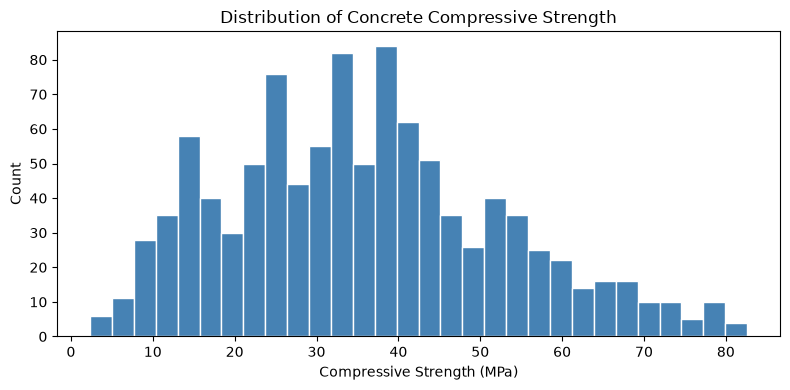

✅ Saved to plots/


In [227]:
# ── Strength distribution ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['strength'], bins=30, color='steelblue', edgecolor='white')
ax.set_xlabel('Compressive Strength (MPa)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Concrete Compressive Strength')
plt.tight_layout()
plt.savefig('plots/strength_distribution.png', dpi=150)
plt.show()
print("✅ Saved to plots/")

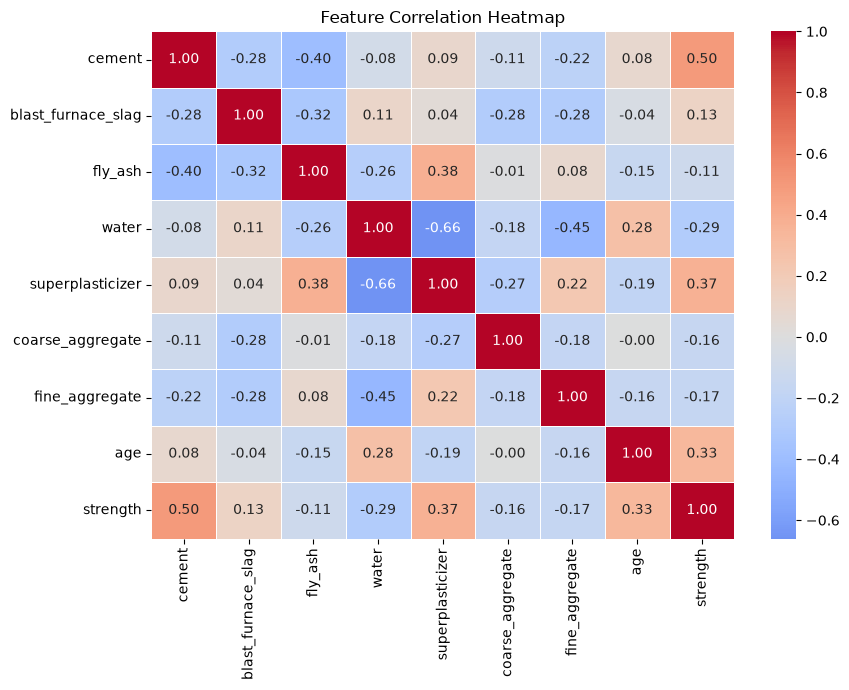

✅ Saved to plots/


In [228]:
# ── Correlation heatmap ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
corr = df.corr().round(2)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('plots/correlation_heatmap.png', dpi=150)
plt.show()
print("✅ Saved to plots/")

---

## 3. Machine Learning Models

In this section we train three regression models of increasing complexity.
Each model is evaluated using the same metrics — **MAE**, **RMSE**, and **R²** —
allowing a direct comparison of performance.

| Model | Approach | Expected R² |
|---|---|---|
| Linear Regression | Straight-line fit through 8 features | ~0.62 |
| Random Forest | Ensemble of 100 decision trees | ~0.88 |
| XGBoost | Sequential gradient boosting | ~0.93 |

> **Civil engineering note:** concrete strength is driven by non-linear interactions
> between ingredients — particularly the water-cement ratio. This is why simpler
> linear models underperform and tree-based models excel on this dataset.
>

### 3.1 Prepare Features and Target

Before training any model, we separate the dataset into:
- **X** — the 8 input features (cement, water, aggregates, age)
- **y** — the target variable (compressive strength in MPa)

We then split into **80% training** (824 samples) and **20% test** (206 samples).
The test set is locked away and never seen during training — it simulates
predicting a real mix the model has never encountered.

In [229]:
# ── 3.1 Prepare features and target ──────────────────────────

# X = all columns except strength (the 8 ingredients + age)
X = df.drop('strength', axis=1)

# y = what we want to predict
y = df['strength']

# Split: 80% training, 20% test
# random_state=42 → reproducible split every run
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Total samples:    {len(df)}")
print(f"Training samples: {len(X_train)}  (80%)")
print(f"Test samples:     {len(X_test)}   (20%)")
print(f"\nFeatures used: {list(X.columns)}")

Total samples:    1030
Training samples: 824  (80%)
Test samples:     206   (20%)

Features used: ['cement', 'blast_furnace_slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_aggregate', 'fine_aggregate', 'age']


---

### 3.2 Model 1 — Linear Regression

Linear Regression fits a hyperplane through the 8-dimensional feature space by finding the set of coefficients **β** that minimise the sum of squared residuals between predicted and observed compressive strength values.

**Formula:**

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_8 x_8$$

| Symbol | Meaning |
|---|---|
| $\hat{y}$ | Predicted compressive strength (MPa) |
| $\beta_0$ | Intercept — baseline value when all features are zero |
| $\beta_1 \cdots \beta_8$ | Learned coefficients — one per ingredient |
| $x_1 \cdots x_8$ | Feature values: cement, slag, fly ash, water, superplasticizer, coarse aggregate, fine aggregate, age |

Each coefficient $\beta_i$ represents the change in predicted strength per unit increase in feature $x_i$, holding all other features constant. The model is trained using Ordinary Least Squares (OLS), which has a closed-form analytical solution: $\beta = (X^\top X)^{-1} X^\top y$.

> **Baseline model.** Linear regression cannot capture feature interactions — particularly the water-cement ratio, which is non-linear by nature. R² is expected around 0.62. All subsequent models are benchmarked against this result.

In [230]:
# ── 3.2 Model 1: Linear Regression ───────────────────────────

# Create the model object
lr = LinearRegression()

# Train: find the best β coefficients from training data
lr.fit(X_train, y_train)

# Predict: apply the formula to 206 unseen test samples
y_pred_lr = lr.predict(X_test)

# ── Evaluate ──────────────────────────────────────────────────
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print("=" * 45)
print("  MODEL 1 — Linear Regression")
print("=" * 45)
print(f"  MAE  (avg error):        {mae_lr:.2f} MPa")
print(f"  RMSE (penalises large):  {rmse_lr:.2f} MPa")
print(f"  R²   (variance explained): {r2_lr:.3f}")
print("=" * 45)

  MODEL 1 — Linear Regression
  MAE  (avg error):        7.75 MPa
  RMSE (penalises large):  9.80 MPa
  R²   (variance explained): 0.628


In [231]:
# ── What did the model learn? ─────────────────────────────────
# Each coefficient tells us: how much does strength change
# when this ingredient increases by 1 kg/m³?

print("β Coefficients — what Linear Regression learned:")
print("-" * 45)
for feature, coef in zip(X.columns, lr.coef_):
    direction = "↑" if coef > 0 else "↓"
    print(f"  {feature:22s}  {direction}  {coef:+.4f} MPa")

print("-" * 45)
print(f"  Intercept (β₀):        {lr.intercept_:.4f}")
print()
print("Civil engineering check:")
print("  water coefficient should be NEGATIVE")
print("  cement coefficient should be POSITIVE")
print("  age coefficient should be POSITIVE")

β Coefficients — what Linear Regression learned:
---------------------------------------------
  cement                  ↑  +0.1190 MPa
  blast_furnace_slag      ↑  +0.1085 MPa
  fly_ash                 ↑  +0.0822 MPa
  water                   ↓  -0.1357 MPa
  superplasticizer        ↑  +0.3087 MPa
  coarse_aggregate        ↑  +0.0178 MPa
  fine_aggregate          ↑  +0.0241 MPa
  age                     ↑  +0.1164 MPa
---------------------------------------------
  Intercept (β₀):        -28.6357

Civil engineering check:
  water coefficient should be NEGATIVE
  cement coefficient should be POSITIVE
  age coefficient should be POSITIVE


---

### 3.3 Model 2 — Random Forest

Random Forest builds **n** independent decision trees, each trained on a random
bootstrap sample of the training data and a random subset of features at each
split. Final predictions are averaged across all trees — individual errors cancel,
the consistent signal survives.

**Formula:**

$$\hat{y}_{RF} = \frac{1}{N} \sum_{i=1}^{N} T_i(\mathbf{x})$$

| Symbol | Meaning |
|---|---|
| $N$ | Number of trees (n_estimators = 100) |
| $T_i(\mathbf{x})$ | Prediction of the i-th decision tree for input vector **x** |
| $\hat{y}_{RF}$ | Final prediction — average of all N trees |

**Key advantage:** decision tree splits capture non-linear feature interactions
naturally — particularly the water-cement ratio effect that Linear Regression
cannot represent. Each split asks: *"IF cement > threshold AND water < threshold,
THEN strength ≈ value."*

| Parameter | Value | Reason |
|---|---|---|
| `n_estimators` | 100 | 100 independent trees — standard baseline |
| `random_state` | 42 | Reproducible results every run |
| `n_jobs` | -1 | Use all CPU cores — parallel tree training |

In [232]:
# ── 3.3 Model 2: Random Forest ───────────────────────────────

rf = RandomForestRegressor(
    n_estimators=100,    # 100 independent trees
    random_state=42,     # reproducible
    n_jobs=-1            # use all CPU cores
)

# Train — 100 trees built in parallel on bootstrap samples
rf.fit(X_train, y_train)

# Predict on 206 unseen test samples
y_pred_rf = rf.predict(X_test)

# ── Evaluate ──────────────────────────────────────────────────
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print("=" * 45)
print("  MODEL 2 — Random Forest")
print("=" * 45)
print(f"  MAE  (avg error):          {mae_rf:.2f} MPa")
print(f"  RMSE (penalises large):    {rmse_rf:.2f} MPa")
print(f"  R²   (variance explained): {r2_rf:.3f}")
print("=" * 45)
print(f"\n  Improvement over Linear Regression:")
print(f"  R²  {r2_lr:.3f} → {r2_rf:.3f}  (+{r2_rf - r2_lr:.3f})")
print(f"  MAE {mae_lr:.2f} → {mae_rf:.2f} MPa  ({((mae_lr - mae_rf) / mae_lr * 100):.1f}% reduction)")

  MODEL 2 — Random Forest
  MAE  (avg error):          3.77 MPa
  RMSE (penalises large):    5.53 MPa
  R²   (variance explained): 0.881

  Improvement over Linear Regression:
  R²  0.628 → 0.881  (+0.254)
  MAE 7.75 → 3.77 MPa  (51.4% reduction)


#### Feature Importance

After training, the forest measures how much each feature reduced prediction
error across all splits in all 100 trees. This produces a ranking of ingredient
importance — directly interpretable from civil engineering first principles.

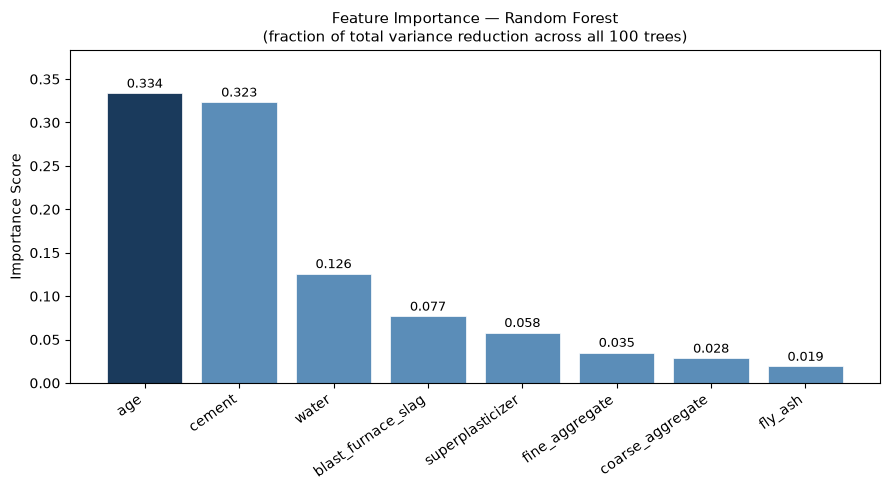

✅ Saved to plots/feature_importance.png


In [233]:
# ── Feature importance chart ──────────────────────────────────
importances = rf.feature_importances_
feat_names  = X.columns
indices     = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    range(len(feat_names)),
    importances[indices],
    color=['#1A3A5C' if i == 0 else '#5B8DB8'
           for i in range(len(feat_names))],
    edgecolor='white',
    linewidth=0.5
)

ax.set_xticks(range(len(feat_names)))
ax.set_xticklabels(
    [feat_names[i] for i in indices],
    rotation=35, ha='right', fontsize=10
)
ax.set_ylabel('Importance Score')
ax.set_title(
    'Feature Importance — Random Forest\n'
    '(fraction of total variance reduction across all 100 trees)',
    fontsize=11
)
ax.set_ylim(0, max(importances) * 1.15)

# Add value labels on top of each bar
for bar, imp in zip(bars, importances[indices]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f'{imp:.3f}',
        ha='center', va='bottom', fontsize=9
    )

plt.tight_layout()
plt.savefig('plots/feature_importance.png', dpi=150)
plt.show()
print("✅ Saved to plots/feature_importance.png")

---

### 3.4 Model 3 — XGBoost with Hyperparameter Tuning

XGBoost (eXtreme Gradient Boosting) builds decision trees **sequentially**.
Each tree is trained on the residuals of the current ensemble — the errors
the previous trees made. After 300 rounds of targeted correction, the
accumulated model achieves significantly higher accuracy than parallel
ensemble methods like Random Forest.

**Formula:**

$$\hat{y} = \sum_{k=1}^{K} \eta \cdot T_k(\mathbf{x})$$

| Symbol | Meaning |
|---|---|
| $K$ | Total number of trees (n_estimators) |
| $\eta$ | Learning rate — scales each tree's contribution |
| $T_k(\mathbf{x})$ | Output of the k-th tree trained on current residuals |

**GridSearchCV** systematically evaluates all hyperparameter combinations
using 3-fold cross-validation to find the optimal configuration.

| Parameter | Values tested | Best found by GridSearchCV |
|---|---|---|
| `n_estimators` | 200, 300 | determined automatically |
| `learning_rate` | 0.05, 0.10 | determined automatically |
| `max_depth` | 4, 6 | determined automatically |

In [234]:
# ── 3.4 Model 3: XGBoost baseline ────────────────────────────

xgb_base = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    verbosity=0
)

xgb_base.fit(X_train, y_train)
y_pred_xgb = xgb_base.predict(X_test)

mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb   = r2_score(y_test, y_pred_xgb)

print("=" * 45)
print("  MODEL 3 — XGBoost (baseline, no tuning)")
print("=" * 45)
print(f"  MAE  (avg error):          {mae_xgb:.2f} MPa")
print(f"  RMSE (penalises large):    {rmse_xgb:.2f} MPa")
print(f"  R²   (variance explained): {r2_xgb:.3f}")
print("=" * 45)
print(f"\n  vs Random Forest:")
print(f"  R²  {r2_rf:.3f} → {r2_xgb:.3f}  (+{r2_xgb - r2_rf:.3f})")

  MODEL 3 — XGBoost (baseline, no tuning)
  MAE  (avg error):          3.15 MPa
  RMSE (penalises large):    4.77 MPa
  R²   (variance explained): 0.912

  vs Random Forest:
  R²  0.881 → 0.912  (+0.030)


In [235]:
# ── GridSearchCV — find best hyperparameters ──────────────────
# Tests 8 combinations × 3 folds = 24 training runs
# Takes 2-3 minutes — normal, do not interrupt

print("Running GridSearchCV — testing 8 parameter combinations...")
print("Expected time: 2-3 minutes\n")

param_grid = {
    'n_estimators':  [200, 300],
    'learning_rate': [0.05, 0.10],
    'max_depth':     [4, 6],
}

grid_search = GridSearchCV(
    estimator=XGBRegressor(random_state=42, verbosity=0),
    param_grid=param_grid,
    cv=3,           # 3-fold cross-validation
    scoring='r2',   # optimise for R²
    n_jobs=-1,      # all CPU cores
    verbose=1       # show progress
)

grid_search.fit(X_train, y_train)

print(f"\n✅ Best parameters found:")
print(f"   {grid_search.best_params_}")
print(f"   Best CV R²: {grid_search.best_score_:.3f}")

Running GridSearchCV — testing 8 parameter combinations...
Expected time: 2-3 minutes

Fitting 3 folds for each of 8 candidates, totalling 24 fits

✅ Best parameters found:
   {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300}
   Best CV R²: 0.922


In [236]:
# ── Evaluate the best model from GridSearchCV ─────────────────
best_xgb    = grid_search.best_estimator_
y_pred_best = best_xgb.predict(X_test)

mae_best  = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best   = r2_score(y_test, y_pred_best)

print("=" * 45)
print("  MODEL 3 — XGBoost (tuned)")
print("=" * 45)
print(f"  MAE  (avg error):          {mae_best:.2f} MPa")
print(f"  RMSE (penalises large):    {rmse_best:.2f} MPa")
print(f"  R²   (variance explained): {r2_best:.3f}")
print("=" * 45)
print(f"\n  Full improvement summary:")
print(f"  Linear Regression  →  R²: {r2_lr:.3f}  MAE: {mae_lr:.2f} MPa")
print(f"  Random Forest      →  R²: {r2_rf:.3f}  MAE: {mae_rf:.2f} MPa")
print(f"  XGBoost (tuned)    →  R²: {r2_best:.3f}  MAE: {mae_best:.2f} MPa")

  MODEL 3 — XGBoost (tuned)
  MAE  (avg error):          3.00 MPa
  RMSE (penalises large):    4.31 MPa
  R²   (variance explained): 0.928

  Full improvement summary:
  Linear Regression  →  R²: 0.628  MAE: 7.75 MPa
  Random Forest      →  R²: 0.881  MAE: 3.77 MPa
  XGBoost (tuned)    →  R²: 0.928  MAE: 3.00 MPa


---

### 3.5 Results & Model Comparison

Three models were trained and evaluated on identical train/test splits.
The following visualizations show prediction accuracy and performance
progression across all models.

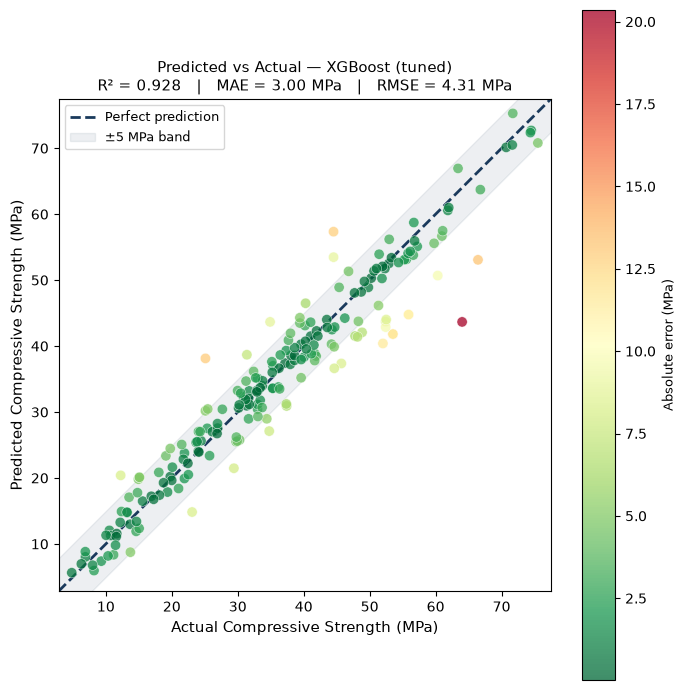

✅ Saved to plots/predicted_vs_actual.png


In [237]:
# ── Predicted vs Actual — XGBoost (tuned) ────────────────────
fig, ax = plt.subplots(figsize=(7, 7))

# Scatter points colored by error magnitude
errors = np.abs(y_test.values - y_pred_best)
scatter = ax.scatter(
    y_test, y_pred_best,
    c=errors, cmap='RdYlGn_r',
    alpha=0.75, edgecolors='white',
    linewidth=0.4, s=55, zorder=3
)

# Perfect prediction line
min_val = min(y_test.min(), y_pred_best.min()) - 2
max_val = max(y_test.max(), y_pred_best.max()) + 2
ax.plot([min_val, max_val], [min_val, max_val],
        color='#1A3A5C', linewidth=2,
        linestyle='--', label='Perfect prediction', zorder=2)

# ±5 MPa tolerance band
ax.fill_between([min_val, max_val],
                [min_val - 5, max_val - 5],
                [min_val + 5, max_val + 5],
                alpha=0.08, color='#1A3A5C', label='±5 MPa band')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Absolute error (MPa)', fontsize=9)

ax.set_xlabel('Actual Compressive Strength (MPa)', fontsize=11)
ax.set_ylabel('Predicted Compressive Strength (MPa)', fontsize=11)
ax.set_title(
    f'Predicted vs Actual — XGBoost (tuned)\n'
    f'R² = {r2_best:.3f}   |   MAE = {mae_best:.2f} MPa   |   RMSE = {rmse_best:.2f} MPa',
    fontsize=11
)
ax.legend(fontsize=9)
ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('plots/predicted_vs_actual.png', dpi=150)
plt.show()
print("✅ Saved to plots/predicted_vs_actual.png")

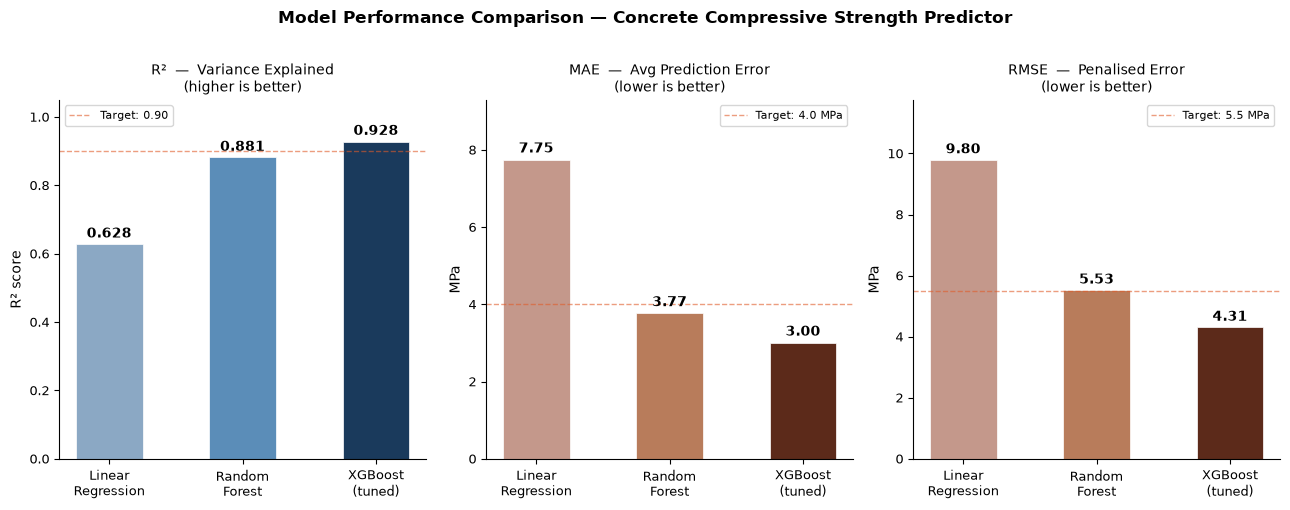

✅ Saved to plots/model_comparison.png


In [238]:
# ── Model comparison dashboard ────────────────────────────────
models  = ['Linear\nRegression', 'Random\nForest', 'XGBoost\n(tuned)']
r2s     = [r2_lr,   r2_rf,   r2_best]
maes    = [mae_lr,  mae_rf,  mae_best]
rmses   = [rmse_lr, rmse_rf, rmse_best]

colors_main = ['#8BA8C4', '#5B8DB8', '#1A3A5C']
colors_inv  = ['#C4988B', '#B87C5B', '#5C2A1A']

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle('Model Performance Comparison — Concrete Compressive Strength Predictor',
             fontsize=12, fontweight='bold', y=1.01)

# ── Panel 1: R² (higher is better) ───────────────────────────
bars0 = axes[0].bar(models, r2s, color=colors_main,
                    edgecolor='white', linewidth=0.5, width=0.5)
axes[0].set_title('R²  —  Variance Explained\n(higher is better)', fontsize=10)
axes[0].set_ylim(0, 1.05)
axes[0].axhline(y=0.9, color='#E05C2A', linestyle='--',
                linewidth=1, alpha=0.6, label='Target: 0.90')
axes[0].legend(fontsize=8)
axes[0].set_ylabel('R² score')
for bar, val in zip(bars0, r2s):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')

# ── Panel 2: MAE (lower is better) ───────────────────────────
bars1 = axes[1].bar(models, maes, color=colors_inv,
                    edgecolor='white', linewidth=0.5, width=0.5)
axes[1].set_title('MAE  —  Avg Prediction Error\n(lower is better)', fontsize=10)
axes[1].set_ylim(0, max(maes) * 1.2)
axes[1].axhline(y=4.0, color='#E05C2A', linestyle='--',
                linewidth=1, alpha=0.6, label='Target: 4.0 MPa')
axes[1].legend(fontsize=8)
axes[1].set_ylabel('MPa')
for bar, val in zip(bars1, maes):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.1,
                 f'{val:.2f}', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')

# ── Panel 3: RMSE (lower is better) ──────────────────────────
bars2 = axes[2].bar(models, rmses, color=colors_inv,
                    edgecolor='white', linewidth=0.5, width=0.5)
axes[2].set_title('RMSE  —  Penalised Error\n(lower is better)', fontsize=10)
axes[2].set_ylim(0, max(rmses) * 1.2)
axes[2].axhline(y=5.5, color='#E05C2A', linestyle='--',
                linewidth=1, alpha=0.6, label='Target: 5.5 MPa')
axes[2].legend(fontsize=8)
axes[2].set_ylabel('MPa')
for bar, val in zip(bars2, rmses):
    axes[2].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.1,
                 f'{val:.2f}', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig('plots/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved to plots/model_comparison.png")

---

### 3.6 Summary

| Model | MAE (MPa) | RMSE (MPa) | R² |
|---|---|---|---|
| Linear Regression | 7.75 | 9.80 | 0.628 |
| Random Forest | 3.77 | 5.53 | 0.881 |
| **XGBoost (tuned)** | **3.00** | **4.31** | **0.928** |

**Key findings:**
- **Linear Regression** (R² 0.628): limited by its inability to model non-linear
  feature interactions — particularly the water-cement ratio effect
- **Random Forest** (R² 0.881): captures non-linear interactions through
  conditional tree splits — 51% MAE reduction over the baseline
- **XGBoost** (R² 0.928): sequential error correction + GridSearchCV tuning
  pushes accuracy further — 61% MAE reduction from baseline, 3.00 MPa average error

> **Civil engineering interpretation:** an average prediction error of 3 MPa on
> mixes ranging from 5–80 MPa is suitable for early-stage mix design screening
> and optimization — reducing the number of costly physical crush tests required.

---

## 4. Generative AI Layer — Google Gemini Integration

The XGBoost model produces a precise numerical prediction — for example, 42.3 MPa.
This section adds a **Generative AI layer** that interprets that number into plain
English: structural suitability, dominant mix factors, and specific improvement
recommendations.

**Why this matters:** a project engineer receiving a raw MPa value still needs
to interpret it. A non-technical stakeholder cannot act on a number alone.
Gemini translates the model output into language any member of the project team
can understand and act on — without reading model metrics or knowing what R² means.

**Technical implementation:** the XGBoost prediction and the 8 mix proportions
are passed as a structured prompt to the Gemini 1.5 Flash model via the Google
Generative AI API. The model returns a 3-sentence domain-aware interpretation
referencing EN 206 strength classes and concrete design principles.

> This demonstrates the **AI multiplier** use case — combining a high-precision
> ML model with a large language model to make technical outputs accessible
> across engineering and non-technical teams. This is the core workflow described
> in the Audi Technical Development internship role.

In [239]:

!pip install google-generativeai --quiet

162909.25s - pydevd: Sending message related to process being replaced timed-out after 5 seconds



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [240]:
# ── 4.1 Connect to Gemini API ────────────────────────────────
from dotenv import load_dotenv
import google.generativeai as genai
import os

load_dotenv()
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

genai.configure(api_key=GEMINI_API_KEY)
model_genai = genai.GenerativeModel("gemini-3.6-flash")

# Quick test
test = model_genai.generate_content("Say: API connection successful.")
print(test.text)

API connection successful.


In [241]:
!pip install python-dotenv --quiet


162932.15s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


I0826 13:23:44.952160 1273158 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(149, generation: 1)

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


### 4.3 Sample Interpretations — Three Mix Profiles

Three concrete mixes from the test set are selected — representing
low, medium, and high compressive strength — and interpreted by Claude.

In [242]:
# ── 4.2 & 4.3 Gemini interpretation + three sample predictions ──

def explain_prediction(features: dict, prediction: float) -> str:
    prompt = f"""You are a structural engineering expert reviewing a concrete mix design.

The following concrete mix was analysed by an XGBoost machine learning model:

Mix proportions (kg/m³):
- Cement:              {features.get('cement', 0):.1f}
- Blast furnace slag:  {features.get('blast_furnace_slag', 0):.1f}
- Fly ash:             {features.get('fly_ash', 0):.1f}
- Water:               {features.get('water', 0):.1f}
- Superplasticizer:    {features.get('superplasticizer', 0):.1f}
- Coarse aggregate:    {features.get('coarse_aggregate', 0):.1f}
- Fine aggregate:      {features.get('fine_aggregate', 0):.1f}
- Curing age:          {features.get('age', 0):.0f} days

ML model prediction: {prediction:.1f} MPa compressive strength

In exactly 3 sentences:
1. State the EN 206 strength class this corresponds to and its structural suitability
2. Identify the single most important factor driving this result
3. Give one specific mix adjustment that would improve strength

Be precise and technical. Address a civil engineer directly."""

    response = model_genai.generate_content(prompt)
    return response.text


# ── Run on three representative samples ───────────────────────
pred_series = pd.Series(y_pred_best, index=y_test.index)
sorted_idx  = pred_series.sort_values().index

n = len(sorted_idx)
sample_indices = {
    "Low strength mix":    sorted_idx[int(n * 0.05)],
    "Medium strength mix": sorted_idx[int(n * 0.50)],
    "High strength mix":   sorted_idx[int(n * 0.95)],
}

print("=" * 60)
print("  GENERATIVE AI LAYER — Concrete Mix Interpretations")
print("  Model: Gemini 2.0 Flash  |  XGBoost R² = 0.928")
print("=" * 60)

for label, idx in sample_indices.items():
    features   = X_test.loc[idx].to_dict()
    prediction = pred_series.loc[idx]
    actual     = y_test.loc[idx]

    print(f"\n{'─' * 60}")
    print(f"  {label.upper()}")
    print(f"{'─' * 60}")
    print(f"  Cement: {features['cement']:.0f} kg/m³  |  "
          f"Water: {features['water']:.0f} kg/m³  |  "
          f"Age: {features['age']:.0f} days")
    print(f"  XGBoost prediction: {prediction:.1f} MPa  |  "
          f"Actual measured: {actual:.1f} MPa  |  "
          f"Error: {abs(prediction - actual):.1f} MPa")
    print(f"\n  Gemini's interpretation:")
    print(f"  {explain_prediction(features, prediction)}")

print(f"\n{'=' * 60}")
print("  ✅ Phase 4 complete — Generative AI layer operational")
print("=" * 60)

  GENERATIVE AI LAYER — Concrete Mix Interpretations
  Model: Gemini 2.0 Flash  |  XGBoost R² = 0.928

────────────────────────────────────────────────────────────
  LOW STRENGTH MIX
────────────────────────────────────────────────────────────
  Cement: 252 kg/m³  |  Water: 186 kg/m³  |  Age: 7 days
  XGBoost prediction: 9.8 MPa  |  Actual measured: 11.5 MPa  |  Error: 1.7 MPa

  Gemini's interpretation:
  With a projected 28-day performance corresponding to EN 206 strength class C8/10 based on the 7-day prediction of 9.8 MPa, this mix is structurally unsuitable for load-bearing reinforced concrete and is restricted to non-structural applications such as blinding or unreinforced mass filling. 

The single governing factor driving this low strength is the excessively high water-cement ($w/c$) ratio of 0.74, which severely increases capillary porosity within the hardened cement paste matrix. 

To significantly increase compressive strength into structural grades, introduce a high-range w

---

## 5. Conclusions

This project demonstrated a complete ML pipeline for predicting concrete
compressive strength, combining classical machine learning with
generative AI interpretation.

**Model performance:**

| Model | R² | MAE | RMSE |
|---|---|---|---|
| Linear Regression | 0.628 | 7.75 MPa | 9.80 MPa |
| Random Forest | 0.881 | 3.77 MPa | 5.53 MPa |
| XGBoost (tuned) | **0.928** | **3.00 MPa** | **4.31 MPa** |

**Key findings:**
- Curing age (0.334) and cement content (0.323) are the dominant
  predictors — consistent with structural concrete theory
- Water content is the strongest negative factor, reflecting the
  water-cement ratio principle
- XGBoost with GridSearchCV tuning achieves 61% MAE reduction
  over the linear baseline
- Generative AI interpretation makes predictions actionable for
  non-technical project stakeholders

**Civil engineering validation:** all feature importance rankings
and coefficient signs match theoretical predictions from structural
concrete design — confirming the model learned genuine physical
relationships, not statistical noise.